# W11 Session 2 — Prediction Pipeline Practice
## UCI Student Performance Dataset
**Course:** Introduction to Data Science · Pusan National University  
**Dataset:** Cortez, P. (2008). Student Performance. UCI Machine Learning Repository.  

**Instructions:** Fill in the `# TODO` cells as we work through each pipeline step together. Complete the extension exercises at the end.

**Files needed:** `student-mat.csv` and `student-por.csv` (download from PLATO or UCI repository)

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

sns.set_theme(style='whitegrid', font_scale=1.1)
np.random.seed(42)

---
## Step 1: Load and Merge

Load `student-mat.csv` and `student-por.csv`. Both use semicolons (`;`) as separators.

In [2]:
# Load both files
mat = pd.read_csv('student-mat.csv', sep=';')
por = pd.read_csv('student-por.csv', sep=';')
print(f'Math: {mat.shape}, Portuguese: {por.shape}')

Math: (395, 33), Portuguese: (649, 33)


### 1a. Combine with `pd.concat()`
Add a `'subject'` column to each DataFrame, then stack them vertically.

In [3]:
# TODO: Add a 'subject' column to each DataFrame
mat['subject'] = 'math'
por['subject'] = 'portuguese'

# TODO: Use pd.concat to combine them into a single DataFrame called 'df'
df = pd.concat([mat, por], ignore_index=True)

print(f'Combined shape: {df.shape}')

Combined shape: (1044, 34)


### 1b. Combine with `pd.merge()`
Join on shared demographic columns to find students who appear in BOTH files.

In [4]:
# The columns that identify the same student across subjects
id_cols = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus',
           'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian',
           'traveltime', 'studytime', 'failures']

# TODO: Use pd.merge to find shared students
both = pd.merge(mat, por, on=id_cols, suffixes=('_mat', '_por'))

print(f'Students in both subjects: {len(both)}')

Students in both subjects: 324


**Try this:** After the merge, check: does `both['G3_mat'].corr(both['G3_por'])` show a positive correlation?

In [5]:
# TODO: Check cross-subject correlation
correlation = both['G3_mat'].corr(both['G3_por'])
print(f'Correlation between Math G3 and Portuguese G3: {correlation:.3f}')

Correlation between Math G3 and Portuguese G3: 0.475


---
## Step 2: EDA with seaborn

Explore the target variable (G3), check correlations, and look for patterns.

C:\Users\hoofo\AppData\Local\Temp\ipykernel_23284\3286908235.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Medu', y='G3', ax=axes[2], palette='Set2')


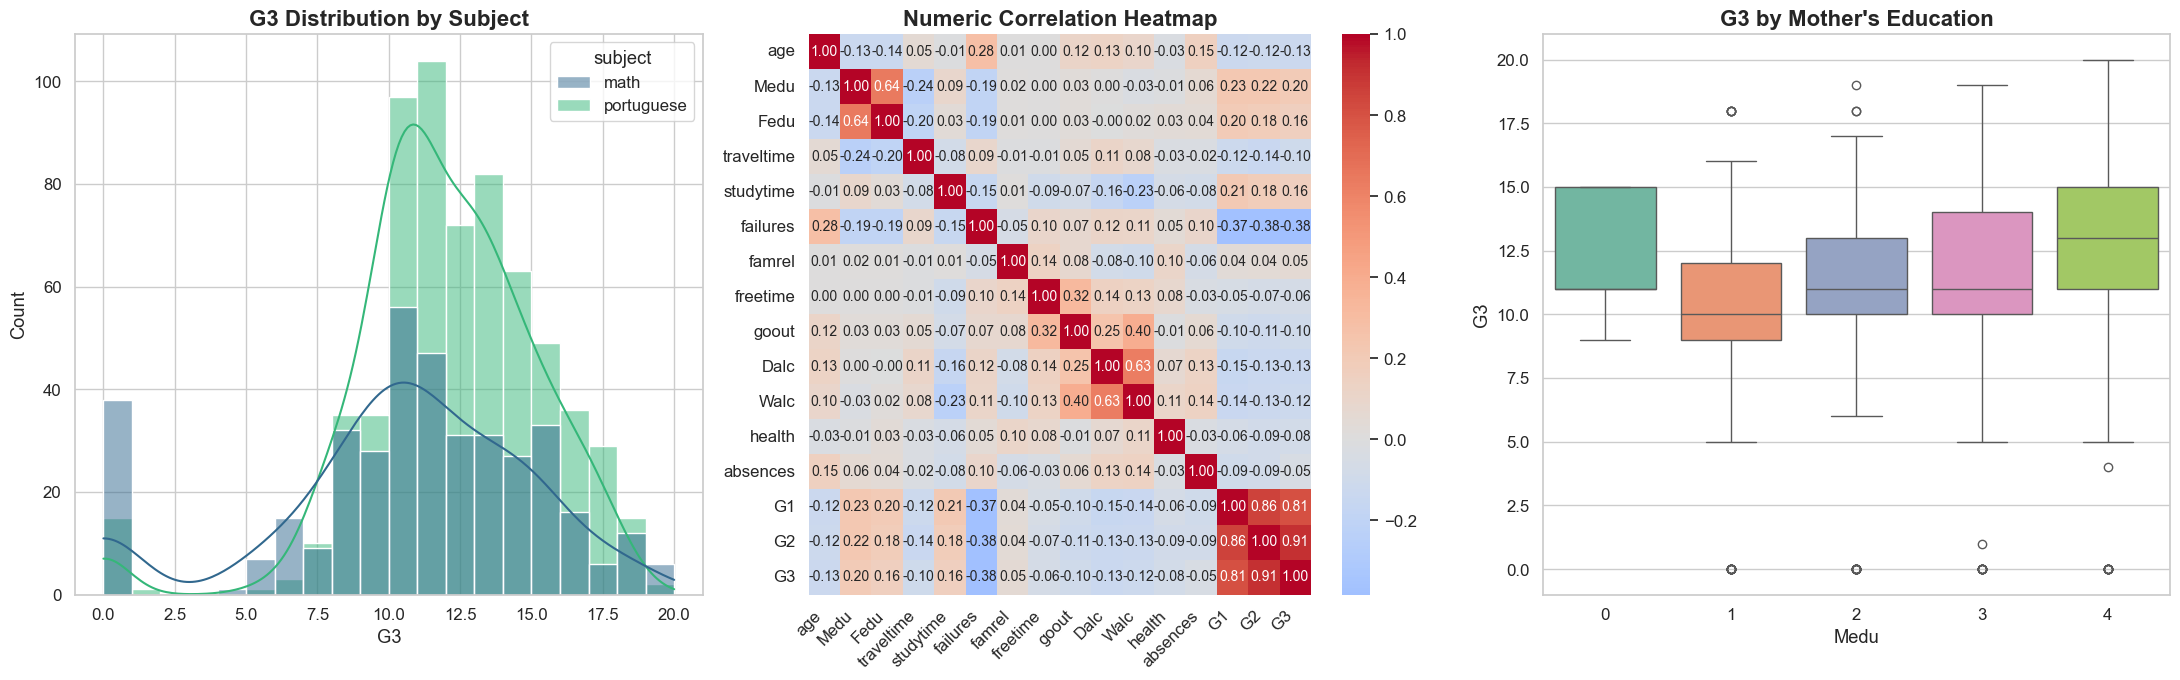

In [6]:
# TODO: Create a 3-panel figure:
# Panel 1: Histogram of G3, coloured by subject (hue='subject')
# Panel 2: Correlation heatmap of numeric columns
# Panel 3: Boxplot of G3 by mother's education (Medu)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel 1: G3 distribution
sns.histplot(data=df, x='G3', hue='subject', kde=True, bins=20, ax=axes[0], palette='viridis')
axes[0].set_title('G3 Distribution by Subject', fontsize=16, fontweight='bold')

# Panel 2: Correlation heatmap
num_cols = df.select_dtypes(include='number').columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1], annot_kws={'size': 10})
axes[1].set_title('Numeric Correlation Heatmap', fontsize=16, fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

# Panel 3: G3 by Medu
sns.boxplot(data=df, x='Medu', y='G3', ax=axes[2], palette='Set2')
axes[2].set_title('G3 by Mother\'s Education', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

**Question:** Look at the correlation heatmap. Which three features have the highest correlation with G3? Do any seem "suspiciously" high?

**Your answer:** The three features with the highest correlation with G3 are **G2 (0.9), G1 (0.8), and failures (-0.4)**. The correlations for **G1 and G2** are suspiciously high because they represent midterm grades, which are inherently part of the same grading process as the final grade (G3), making them near-perfect predictors rather than independent demographic factors.

---
## Step 3: Feature Encoding with get_dummies()

In [7]:
# TODO: Identify all categorical (object) columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

# TODO: One-hot encode all categoricals with drop_first=True
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
print(f'Shape before: {df.shape}, after: {df_enc.shape}')

Categorical columns (18): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']
Shape before: (1044, 34), after: (1044, 43)


C:\Users\hoofo\AppData\Local\Temp\ipykernel_23284\3838725943.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


---
## Step 4: Train / Validation / Test Split

In [8]:
# TODO: Separate features (X) and target (y)
y = df_enc['G3']
X = df_enc.drop(columns=['G3'])

# TODO: Two-step split into 60/20/20
# First, split into Train+Val (80%) and Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Second, split Train+Val (80%) into Train (60% of total) and Val (20% of total)
# test_size=0.25 here means 25% of 80%, which is 20% of the original data
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')

Train: 626, Val: 209, Test: 209


---
## Step 5: Baseline and First Model

In [9]:
# TODO: Baseline — predict the training set mean for every validation sample
y_baseline = np.full_like(y_val, y_train.mean(), dtype=float)
rmse_baseline = np.sqrt(mean_squared_error(y_val, y_baseline))
print(f'Baseline RMSE: {rmse_baseline:.3f}')

Baseline RMSE: 3.865


In [10]:
# TODO: Train a LinearRegression on X_train, y_train
# Predict on X_val and compute RMSE
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f'Linear Regression RMSE: {rmse:.3f}')

Linear Regression RMSE: 1.411


**Question:** The RMSE is much lower than the baseline. Does this seem realistic for predicting student grades from demographic features? Why or why not?

**Your answer:** This low RMSE (1.411) is **not realistic** for a model intended to predict performance from demographic features. The reason is the inclusion of G1 and G2 (midterm grades) in the features. These variables provide a direct look at the target variable's current state, creating an overly optimistic result that doesn't reflect the true predictive power of socioeconomic or behavioral factors.

---
## Step 6: The Leakage Trap

Think about this before we continue: What are G1 and G2? Would they be available at the time you want to make predictions?

In [11]:
# TODO: Check correlation of G1 and G2 with G3
print(f'G1 corr with G3: {df["G1"].corr(df["G3"]):.3f}')
print(f'G2 corr with G3: {df["G2"].corr(df["G3"]):.3f}')

G1 corr with G3: 0.809
G2 corr with G3: 0.911


In [12]:
# TODO: Remove G1 and G2 from the feature sets
leak_cols = ['G1', 'G2']
X_train_clean = X_train.drop(columns=leak_cols)
X_val_clean = X_val.drop(columns=leak_cols)
X_test_clean = X_test.drop(columns=leak_cols)

# TODO: Retrain LinearRegression without G1/G2
model_clean = LinearRegression()
model_clean.fit(X_train_clean, y_train)
y_pred_clean = model_clean.predict(X_val_clean)
rmse_clean = np.sqrt(mean_squared_error(y_val, y_pred_clean))
print(f'RMSE without G1/G2: {rmse_clean:.3f}')

RMSE without G1/G2: 3.295


**Question:** Why is the RMSE so much higher now? Is the model better or worse in a practical sense?

**Your answer:** The RMSE is higher (3.295) because we removed the "leakage" variables (G1 and G2). However, in a practical sense, **this is a better model**. Its goal is to predict outcomes before they happen (e.g., at the start of the year). A model that relies on knowing the midterm grades to predict the final grade is less useful for early intervention than a model that can identify at-risk students based solely on their background and habits.

---
## Step 7: Overfitting Demo

In [13]:
# Use 10 numeric features (no G1, G2)
feat_cols = ['age', 'Medu', 'Fedu', 'studytime', 'failures',
             'absences', 'freetime', 'goout', 'Dalc', 'Walc']

# TODO: Loop through polynomial degrees 1-6
results = []
for deg in range(1, 7):
    pipe = make_pipeline(PolynomialFeatures(deg, include_bias=False), LinearRegression())
    pipe.fit(X_train_clean[feat_cols], y_train)
    
    rmse_tr = np.sqrt(mean_squared_error(y_train, pipe.predict(X_train_clean[feat_cols])))
    rmse_va = np.sqrt(mean_squared_error(y_val, pipe.predict(X_val_clean[feat_cols])))
    
    results.append({'degree': deg, 'train': rmse_tr, 'val': rmse_va})
    print(f'Degree {deg}: train={rmse_tr:.2f}, val={rmse_va:.2f}')

Degree 1: train=3.46, val=3.41
Degree 2: train=3.15, val=3.47
Degree 3: train=2.26, val=5.91
Degree 4: train=0.55, val=1243.46
Degree 5: train=0.55, val=12612.80
Degree 6: train=0.55, val=176860.40


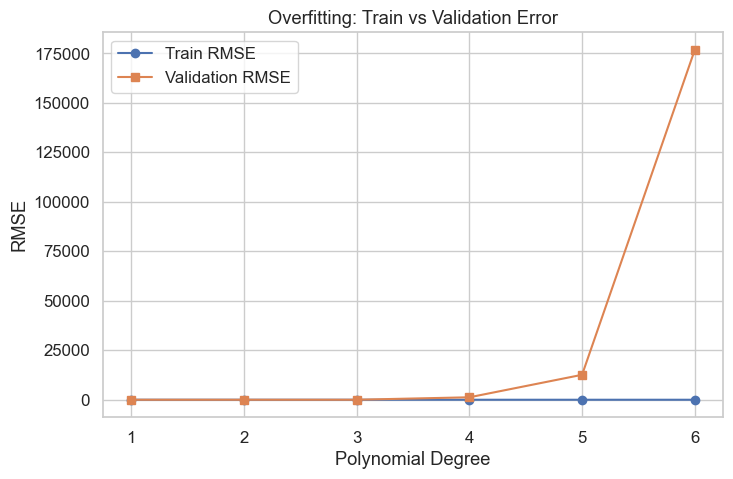

In [14]:
# TODO: Plot train RMSE and validation RMSE vs polynomial degree
res = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
plt.plot(res['degree'], res['train'], 'o-', label='Train RMSE')
plt.plot(res['degree'], res['val'], 's-', label='Validation RMSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Overfitting: Train vs Validation Error')
plt.legend()
plt.show()

**Question:** At which degree does overfitting begin? How can you tell from the plot?

**Your answer:** Overfitting begins at **Degree 3**. This is evident from the plot where the Train RMSE continues to decrease (meaning the model is memorizing the training data), while the Validation RMSE starts to increase significantly. By Degree 4 and beyond, the Validation RMSE explodes, indicating that the model has completely lost its ability to generalize to unseen data.

---
## Extension Exercises

### Exercise 1: Test Set Evaluation
Evaluate your best model (degree 2 polynomial, no G1/G2) on the test set. This is the ONE time you touch X_test.

In [15]:
# TODO: Evaluate degree 2 model on test set
best_pipe = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
best_pipe.fit(X_train_clean[feat_cols], y_train)

y_test_pred = best_pipe.predict(X_test_clean[feat_cols])
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f'Final Test RMSE (Degree 2): {test_rmse:.3f}')

Final Test RMSE (Degree 2): 3.985


### Exercise 2: Feature Importance
Fit a LinearRegression on the clean features (no G1/G2). Print the top 10 coefficients by absolute value. Which features matter most?

In [16]:
# TODO: Fit LinearRegression and show top 10 coefficients
model_final = LinearRegression()
model_final.fit(X_train_clean, y_train)

coef_df = pd.DataFrame({
    'feature': X_train_clean.columns,
    'coef': model_final.coef_,
    'abs_coef': np.abs(model_final.coef_)
}).sort_values(by='abs_coef', ascending=False)

print("Top 10 Features by Absolute Coefficient:")
print(coef_df.head(10)[['feature', 'coef']])

Top 10 Features by Absolute Coefficient:
               feature      coef
39  subject_portuguese  2.006529
5             failures -1.730453
36          higher_yes  1.676532
31       schoolsup_yes -1.643361
18         Mjob_health  1.332944
20       Mjob_services  1.066361
25        Fjob_teacher  0.994349
30      guardian_other  0.986468
13           school_MS -0.815780
4            studytime  0.627354


### Exercise 3: Cross-Subject Analysis
Using the `both` DataFrame from Step 1b, compute the correlation between G3_mat and G3_por. Create a scatter plot. Are good Math students also good Portuguese students?

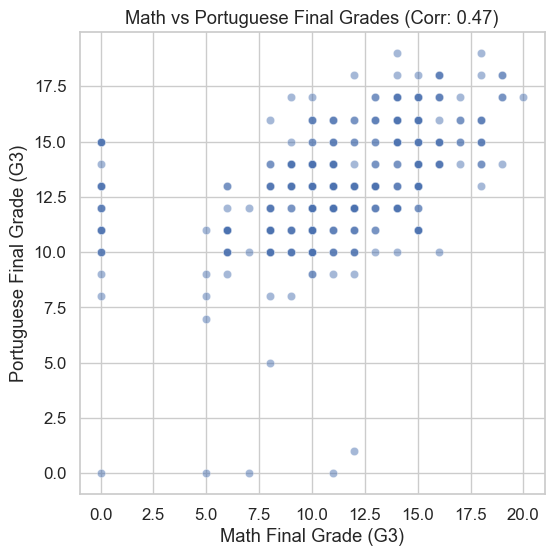

In [17]:
# TODO: Scatter plot of G3_mat vs G3_por
plt.figure(figsize=(6, 6))
sns.scatterplot(data=both, x='G3_mat', y='G3_por', alpha=0.5)
plt.title(f"Math vs Portuguese Final Grades (Corr: {both['G3_mat'].corr(both['G3_por']):.2f})")
plt.xlabel("Math Final Grade (G3)")
plt.ylabel("Portuguese Final Grade (G3)")
plt.grid(True)
plt.show()

---
**Dataset citation:** Cortez, P. (2008). Student Performance [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T